# Isotope Generator Calculator

Simulates a parent→daughter generator on a user-defined event schedule with three operation types:
- **`milk`** — elute the daughter species
- **`topup`** — elute the daughter, extract a fraction of the parent, then replenish parent and/or daughter
- **`addition`** — elute the daughter, then add specified amounts of parent and/or daughter (no extraction)

**Usage:** Edit the **Parameters** cell, then run all cells (`Kernel → Restart & Run All`).

In [2]:
import math, sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.linalg import expm
from pathlib import Path

DB_PATH = Path.cwd() / 'instance' / 'generator.db'
LN2 = math.log(2)
MBQ_PER_MCI = 37

TIME_UNITS = [
    ('s',         1 / 3600),
    ('min',       1 / 60),
    ('h',         1.0),
    ('d',         24.0),
    ('months',    30.4375 * 24),
    ('y',         365.25 * 24),
    ('decades',   10 * 365.25 * 24),
    ('centuries', 100 * 365.25 * 24),
]

def pick_time_unit(half_life_h):
    for label, h_per_unit in TIME_UNITS:
        if 1 <= half_life_h / h_per_unit < 100:
            return label, h_per_unit
    return TIME_UNITS[-1]

def _db_half_life(db, symbol):
    row = db.execute('SELECT half_life_s FROM isotopes WHERE symbol = ?', (symbol,)).fetchone()
    return row[0] if row else None

def _db_branching_ratio(db, parent, daughter):
    row = db.execute(
        'SELECT branching_ratio FROM decay_modes WHERE parent_symbol=? AND daughter_symbol=?',
        (parent, daughter),
    ).fetchone()
    return row[0] if row else 1.0

In [3]:
def simulate_chain_scheduled(
    lambdas,
    branching_ratios,
    N0,
    schedule,
    duration_s,
    topup_ra225_extract_fraction=0.0,
    topup_ra225_add_atoms=0.0,
    topup_ac225_add_atoms=0.0,
    addition_ra225_add_atoms=0.0,
    addition_ac225_add_atoms=0.0,
    n_points_per_interval=20,
):
    """
    Simulate an N-member linear decay chain on a user-defined event schedule.

    schedule : [(time_s, op), ...]
        op = 'milk'     — zero out the last species
        op = 'topup'    — zero out last species, extract fraction of first,
                          add atoms to first and last species
        op = 'addition' — zero out last species, add atoms to first and last species
                          (no extraction)

    All events target species[0] (parent) and species[-1] (daughter).
    Intermediates are never touched by events.

    Returns dict with:
        't_seconds'  : 1-D array
        'N_values'   : list of 1-D arrays, one per species
        'events'     : list of dicts with keys
                         time_s, op, ac225_atoms,
                         ra225_extracted_atoms, ra225_added_atoms, ac225_added_atoms
    """
    n = len(lambdas)
    A = np.diag(-np.array(lambdas, dtype=float))
    for i in range(n - 1):
        A[i + 1, i] = branching_ratios[i] * lambdas[i]

    sorted_sched  = sorted(schedule, key=lambda x: x[0])
    op_by_time    = {float(t): op for t, op in sorted_sched}
    event_times_s = [float(t) for t, _ in sorted_sched]

    segment_bounds = np.array([0.0] + event_times_s + [float(duration_s)])

    t_global = []
    N_global = [[] for _ in range(n)]
    events   = []

    N_seg = np.array(N0, dtype=float)

    for i in range(len(segment_bounds) - 1):
        t_start = segment_bounds[i]
        t_end   = segment_bounds[i + 1]
        local_t = np.linspace(0.0, t_end - t_start, n_points_per_interval)

        N_at_t = np.stack([expm(A * dt) @ N_seg for dt in local_t])

        t_global.append(t_start + local_t)
        for k in range(n):
            N_global[k].append(N_at_t[:, k])

        is_event = i < len(segment_bounds) - 2
        if is_event:
            N_end = N_at_t[-1].copy()
            op    = op_by_time[float(t_end)]

            ac225_harvested = float(N_end[-1])
            ra225_extracted = float(N_end[0] * topup_ra225_extract_fraction) if op == 'topup' else 0.0

            N_next = N_end.copy()
            N_next[-1] = 0.0                                         # milk (all ops)
            if op == 'topup':
                N_next[0] *= (1.0 - topup_ra225_extract_fraction)   # extract
                N_next[0] += topup_ra225_add_atoms
                N_next[-1] += topup_ac225_add_atoms
                ra225_added = topup_ra225_add_atoms
                ac225_added = topup_ac225_add_atoms
            elif op == 'addition':
                N_next[0] += addition_ra225_add_atoms
                N_next[-1] += addition_ac225_add_atoms
                ra225_added = addition_ra225_add_atoms
                ac225_added = addition_ac225_add_atoms
            else:
                ra225_added = 0.0
                ac225_added = 0.0

            events.append({
                'time_s':                float(t_end),
                'op':                    op,
                'ac225_atoms':           ac225_harvested,
                'ra225_extracted_atoms': ra225_extracted,
                'ra225_added_atoms':     ra225_added,
                'ac225_added_atoms':     ac225_added,
            })
            N_seg = N_next
        else:
            N_seg = N_at_t[-1]

    return {
        't_seconds': np.concatenate(t_global),
        'N_values':  [np.concatenate(N_global[k]) for k in range(n)],
        'events':    events,
    }

## Parameters

Edit the values below, then **Kernel → Restart & Run All**.

- `SCHEDULE` is a list of `(day, operation)` tuples. `DURATION_DAYS` sets the simulation end and should be ≥ the last scheduled day.
- Top-up and addition parameters each apply uniformly to every event of their respective type.

In [67]:
# ── Generator pair ────────────────────────────────────────────────────────
PARENT_SYMBOL        = 'Ra-225'
DAUGHTER_SYMBOL      = 'Ac-225'
INTERMEDIATE_SYMBOLS = []       # e.g. ['Ra-225'] for a 3-member chain

# ── Units and initial conditions ──────────────────────────────────────────
UNITS            = 'mCi'    # 'MBq' or 'mCi'
INITIAL_ACTIVITY = 50    # initial parent activity, in UNITS

# ── Event schedule ─────────────────────────────────────────────────────────
# (day, operation) — operations: 'milk', 'topup', or 'addition'
SCHEDULE = [
    (2,  'milk'),
    (4,  'milk'),
    (7,  'addition'),
    (9,  'milk'),
    (11,  'milk'),
    (14, 'addition'),
    (16,  'milk'),
    (18,  'milk'),
    (21, 'addition'),
    (23,  'milk'),
    (25,  'milk'),
    (28, 'addition'),
    (30,  'milk'),
    (32,  'milk'),
    (35, 'addition'),
    (37,  'milk'),
    (39,  'milk'),
    (42, 'addition'),
    (44,  'milk'),
    (46,  'milk'),
    (49, 'topup'),
    (51,  'milk'),
    (53,  'milk'),
    (56,  'topup'),
    (58,  'milk'),
    (60,  'milk'),
    (63, 'topup'),
    (65,  'milk'),
    (67,  'milk'),
    (70, 'topup'),
    (72,  'milk'),
    (74,  'milk'),
    (77, 'topup'),
    (79,  'milk'),
    (81,  'milk'),
    (84, 'topup'),
    (86,  'milk'),
    (88,  'milk'),
    (91, 'topup'),
    (93,  'milk'),
    (95,  'milk'),
    (98,  'topup'),
    (100,  'milk'),
    (102,  'milk'),
    (105, 'topup'),
    (107,  'milk'),
    (109,  'milk'),
    (112, 'topup'),
    (114,  'milk'),
    (116,  'milk'),
    (119, 'topup'),
]
DURATION_DAYS = 122.0

# ── Generator yield ────────────────────────────────────────────────────────
GENERATOR_YIELD_PCT = 100   # % of daughter recovered per milking

# ── Top-up parameters (applied to every 'topup' event) ────────────────────
TOPUP_RA225_EXTRACT_FRACTION = 0.1   # fraction of parent removed  (e.g. 0.10 = 10%)
TOPUP_RA225_ADD              = 50   # parent activity to add back, in UNITS
TOPUP_AC225_ADD              = 6.28   # daughter activity to seed,   in UNITS

# ── Addition parameters (applied to every 'addition' event) ───────────────
ADDITION_RA225_ADD = 50   # parent activity to add, in UNITS
ADDITION_AC225_ADD = 6.28   # daughter activity to add, in UNITS

## Calculation

In [68]:
def to_mbq(v):
    return v * MBQ_PER_MCI if UNITS == 'mCi' else float(v)

def from_mbq(v):
    return v / MBQ_PER_MCI if UNITS == 'mCi' else v

if not SCHEDULE:
    raise ValueError('SCHEDULE is empty.')
if DURATION_DAYS < max(day for day, _ in SCHEDULE):
    raise ValueError('DURATION_DAYS must be >= the last scheduled event day.')

gen_yield            = min(max(GENERATOR_YIELD_PCT, 0), 100) / 100
initial_activity_MBq = to_mbq(INITIAL_ACTIVITY)

db = sqlite3.connect(str(DB_PATH))
try:
    chain_symbols = [PARENT_SYMBOL] + list(INTERMEDIATE_SYMBOLS) + [DAUGHTER_SYMBOL]
    chain_hl_s = []
    for sym in chain_symbols:
        hl = _db_half_life(db, sym)
        if hl is None:
            raise ValueError(f'Unknown isotope: {sym}')
        chain_hl_s.append(hl)
    lambdas   = [LN2 / hl if hl < 1e29 else 0.0 for hl in chain_hl_s]
    chain_brs = [_db_branching_ratio(db, chain_symbols[i], chain_symbols[i + 1])
                 for i in range(len(chain_symbols) - 1)]
finally:
    db.close()

lambda_parent   = lambdas[0]
lambda_daughter = lambdas[-1]

if lambda_parent == 0:
    raise ValueError(f'{PARENT_SYMBOL} is stable and cannot be a generator parent.')

N0 = np.zeros(len(lambdas))
N0[0] = initial_activity_MBq * 1e6 / lambda_parent

topup_ra225_add_atoms    = to_mbq(TOPUP_RA225_ADD)    * 1e6 / lambda_parent   if lambda_parent   > 0 else 0.0
topup_ac225_add_atoms    = to_mbq(TOPUP_AC225_ADD)    * 1e6 / lambda_daughter if lambda_daughter > 0 else 0.0
addition_ra225_add_atoms = to_mbq(ADDITION_RA225_ADD) * 1e6 / lambda_parent   if lambda_parent   > 0 else 0.0
addition_ac225_add_atoms = to_mbq(ADDITION_AC225_ADD) * 1e6 / lambda_daughter if lambda_daughter > 0 else 0.0

schedule_s = [(float(day) * 86400.0, op) for day, op in SCHEDULE]
duration_s = DURATION_DAYS * 86400.0

result = simulate_chain_scheduled(
    lambdas=lambdas,
    branching_ratios=chain_brs,
    N0=N0,
    schedule=schedule_s,
    duration_s=duration_s,
    topup_ra225_extract_fraction=TOPUP_RA225_EXTRACT_FRACTION,
    topup_ra225_add_atoms=topup_ra225_add_atoms,
    topup_ac225_add_atoms=topup_ac225_add_atoms,
    addition_ra225_add_atoms=addition_ra225_add_atoms,
    addition_ac225_add_atoms=addition_ac225_add_atoms,
)

t_seconds = result['t_seconds']
N_values  = result['N_values']
events    = result['events']

A_MBq = [lambdas[k] * N_values[k] / 1e6 for k in range(len(chain_symbols))]

time_label, h_per_unit = pick_time_unit(chain_hl_s[0] / 3600)
t_plot = t_seconds / 3600 / h_per_unit

n_milk     = sum(1 for e in events if e['op'] == 'milk')
n_topup    = sum(1 for e in events if e['op'] == 'topup')
n_addition = sum(1 for e in events if e['op'] == 'addition')
print(f'Chain: {" -> ".join(chain_symbols)}')
print(f'Events: {len(events)} total ({n_milk} milk, {n_topup} top-up, {n_addition} addition) '
      f'over {DURATION_DAYS} days')

Chain: Ra-225 -> Ac-225
Events: 51 total (34 milk, 11 top-up, 6 addition) over 122.0 days


## Decay Chart

Theoretical activity of each species. Dotted lines mark events (grey = milk, green = top-up, blue = addition). The daughter curve drops to zero after every event; top-up and addition events also show a discontinuity on the parent curve.

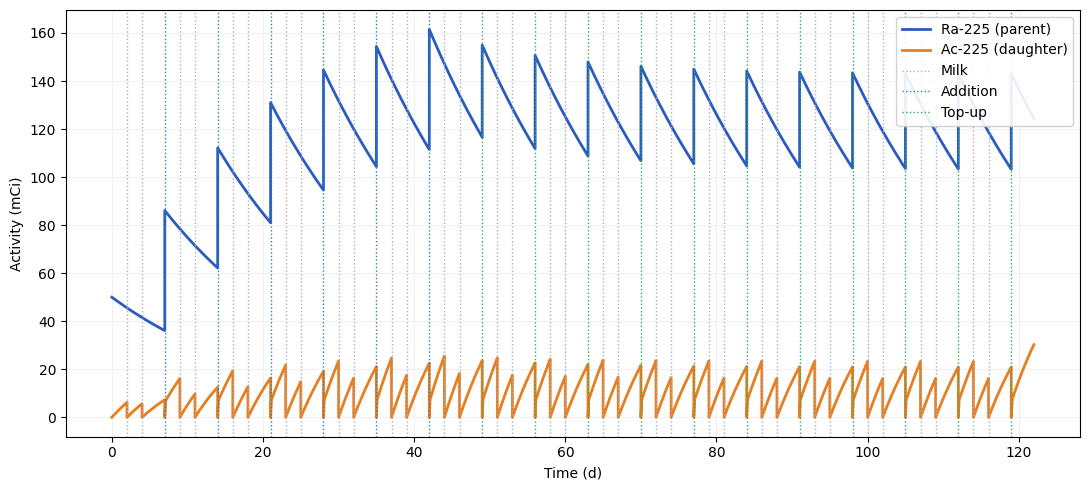

In [69]:
_COLORS_INTER = ['#8e44ad', '#6c3483', '#5b2c6f']
_EVENT_COLORS = {'milk': '#aab0c0', 'topup': '#27ae60', 'addition': '#2980b9'}

def _role_label(i):
    if i == 0:                        return 'parent'
    if i == len(chain_symbols) - 1:   return 'daughter'
    return 'intermediate'

event_times_s_set = {e['time_s'] for e in events}

fig, ax = plt.subplots(figsize=(11, 5))

# Parent and intermediates.
# At topup/addition events the N_values arrays contain two consecutive points at the
# same time (pre- and post-transition), so matplotlib draws the jump automatically.
for k in range(len(chain_symbols) - 1):
    color = '#2a5cbf' if k == 0 else _COLORS_INTER[(k - 1) % len(_COLORS_INTER)]
    ax.plot(t_plot, from_mbq(A_MBq[k]),
            color=color, lw=2, label=f'{chain_symbols[k]} ({_role_label(k)})')

# Daughter — insert explicit zero at each event so the drop is visible
# before any addition raises it again.
t_d, y_d = [], []
for i, (ts, act) in enumerate(zip(t_seconds, A_MBq[-1])):
    t_d.append(ts / 3600 / h_per_unit)
    y_d.append(from_mbq(act))
    if i < len(t_seconds) - 1 and any(abs(ts - te) < 0.5 for te in event_times_s_set):
        t_d.append(ts / 3600 / h_per_unit)
        y_d.append(0.0)

ax.plot(t_d, y_d, color='#e67e22', lw=2,
        label=f'{chain_symbols[-1]} (daughter)')

# Event markers
for e in events:
    ax.axvline(e['time_s'] / 3600 / h_per_unit,
               color=_EVENT_COLORS[e['op']], lw=1, ls='dotted')

# Legend — isotope traces + one entry per event type present in the schedule
handles, labels = ax.get_legend_handles_labels()
seen_ops = dict.fromkeys(e['op'] for e in events)
op_labels = {'milk': 'Milk', 'topup': 'Top-up', 'addition': 'Addition'}
for op in seen_ops:
    handles.append(Line2D([0], [0], color=_EVENT_COLORS[op], lw=1, ls='dotted'))
    labels.append(op_labels[op])
ax.legend(handles=handles, labels=labels, loc='upper right', framealpha=0.9)

ax.set_xlabel(f'Time ({time_label})')
ax.set_ylabel(f'Activity ({UNITS})')
ax.set_facecolor('white')
ax.grid(True, color='#eef0f4')
fig.tight_layout()
plt.show()

## Events Table

Practical yields (after generator yield %). Added/extracted columns are zero for plain milk events.

In [70]:
rows = []
running_ac225 = 0.0

for e in events:
    ac225_yield_mbq = lambda_daughter * e['ac225_atoms']           / 1e6 * gen_yield
    ra225_ext_mbq   = lambda_parent   * e['ra225_extracted_atoms'] / 1e6
    ra225_add_mbq   = lambda_parent   * e['ra225_added_atoms']     / 1e6
    ac225_add_mbq   = lambda_daughter * e['ac225_added_atoms']     / 1e6
    running_ac225  += from_mbq(ac225_yield_mbq)

    rows.append({
        f'Time ({time_label})':         round(e['time_s'] / 3600 / h_per_unit, 2),
        'Operation':                     e['op'],
        f'Ac-225 Yield ({UNITS})':      round(from_mbq(ac225_yield_mbq), 2),
        f'Cumulative Ac-225 ({UNITS})': round(running_ac225, 2),
        f'Ra-225 Extracted ({UNITS})':  round(from_mbq(ra225_ext_mbq), 2),
        f'Ra-225 Added ({UNITS})':      round(from_mbq(ra225_add_mbq), 2),
        f'Ac-225 Added ({UNITS})':      round(from_mbq(ac225_add_mbq), 2),
    })

pd.DataFrame(rows)

,Time (d),Operation,Ac-225 Yield (mCi),Cumulative Ac-225 (mCi),Ra-225 Extracted (mCi),Ra-225 Added (mCi),Ac-225 Added (mCi)
0,2.0,milk,6.22,6.22,0.00,0.0,0.00
1,4.0,milk,5.67,11.89,0.00,0.0,0.00
2,7.0,addition,7.31,19.20,0.00,50.0,6.28
3,9.0,milk,16.17,35.37,0.00,0.0,0.00
4,11.0,milk,9.76,45.13,0.00,0.0,0.00
5,14.0,addition,12.59,57.72,0.00,50.0,6.28
6,16.0,milk,19.42,77.14,0.00,0.0,0.00
7,18.0,milk,12.72,89.85,0.00,0.0,0.00
8,21.0,addition,16.40,106.25,0.00,50.0,6.28
9,23.0,milk,21.76,128.01,0.00,0.0,0.00


## Cumulative Ac-225 Harvest

Running total of practical Ac-225 yield. Bar colour distinguishes event type (milk = light green, top-up = dark green, addition = blue).

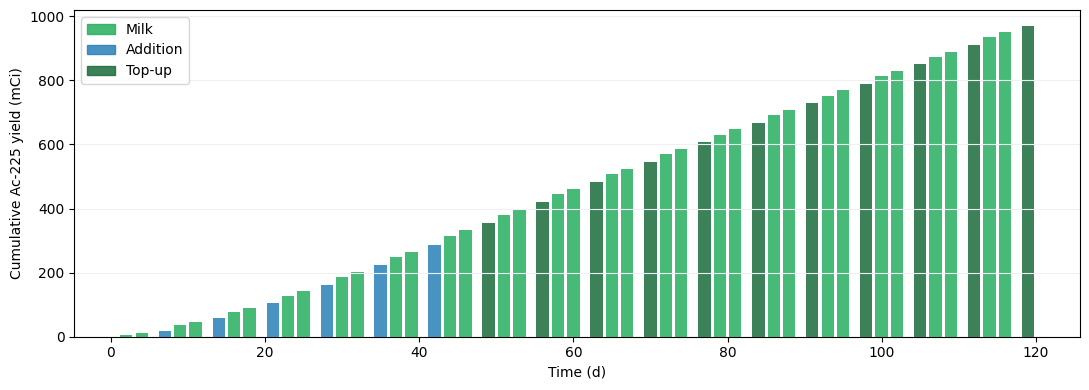

In [71]:
_BAR_COLORS = {'milk': '#27ae60', 'topup': '#1a6b3a', 'addition': '#2980b9'}

times_plot_e = [e['time_s'] / 3600 / h_per_unit for e in events]
bar_colors   = [_BAR_COLORS[e['op']] for e in events]

running = 0.0
cumulative = []
for e in events:
    running += from_mbq(lambda_daughter * e['ac225_atoms'] / 1e6 * gen_yield)
    cumulative.append(running)

bar_width = (
    (times_plot_e[-1] - times_plot_e[0]) / len(times_plot_e) * 0.7
    if len(times_plot_e) > 1 else 1.0
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(times_plot_e, cumulative, width=bar_width, color=bar_colors, alpha=0.85)
ax.set_xlabel(f'Time ({time_label})')
ax.set_ylabel(f'Cumulative Ac-225 yield ({UNITS})')
ax.set_facecolor('white')
ax.grid(True, color='#eef0f4', axis='y')

seen_ops = dict.fromkeys(e['op'] for e in events)
op_labels = {'milk': 'Milk', 'topup': 'Top-up', 'addition': 'Addition'}
legend_handles = [plt.Rectangle((0, 0), 1, 1, color=_BAR_COLORS[op], alpha=0.85) for op in seen_ops]
ax.legend(legend_handles, [op_labels[op] for op in seen_ops], loc='upper left')

fig.tight_layout()
plt.show()